# 27 — Single Case: IG vs SHAP (Camargo Helpdesk)

Side-by-side attribution for a given prefix at the Camargo model:

- **Integrated Gradients** (Captum) with a zero baseline on the embedded + numeric inputs.
- **Shapley Value Sampling** (Captum) as a SHAP-style attribution with the same inputs + baseline. (The stand-alone `shap` library isn't installed; Captum's sampling-based Shapley values are the drop-in alternative.)

Both rows of the heatmap cover the same features (Activity embedding summed, Resource embedding summed, case_elapsed_time).

In [1]:
import sys
from pathlib import Path

_current = Path().resolve()
while _current != _current.parent:
    if (_current / 'src').is_dir() and (_current / 'encoded_data').is_dir():
        break
    _current = _current.parent
_camargo_dir = _current / 'src' / 'interpretability' / 'notebooks' / 'camargo'
for p in [_current, _current / 'src', _camargo_dir]:
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

import _camargo_utils as utils
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

SPEC = utils.HELPDESK
model = utils.load_camargo_model(_current, SPEC)
dataset = utils.load_test_dataset(_current, SPEC)
window = utils.compute_window(dataset)
predictor = utils.CamargoPredictor(model, SPEC, window)
idx_to_name = predictor.idx_to_name
eos_idx = predictor.eos_idx
ACT_IDX = SPEC.cat_indices[0]
feature_names = ['Activity', 'Resource', 'case_elapsed_time']
print(f'{SPEC.name} | window={window}')

Data set categories:  ([('Activity', 16, {'Assign seriousness': 1, 'Closed': 2, 'Create SW anomaly': 3, 'DUPLICATE': 4, 'EOS': 5, 'INVALID': 6, 'Insert ticket': 7, 'RESOLVED': 8, 'Require upgrade': 9, 'Resolve SW anomaly': 10, 'Resolve ticket': 11, 'Schedule intervention': 12, 'Take in charge ticket': 13, 'VERIFIED': 14, 'Wait': 15}), ('Resource', 24, {'EOS': 1, 'Value 1': 2, 'Value 10': 3, 'Value 11': 4, 'Value 12': 5, 'Value 13': 6, 'Value 14': 7, 'Value 15': 8, 'Value 16': 9, 'Value 17': 10, 'Value 18': 11, 'Value 19': 12, 'Value 2': 13, 'Value 20': 14, 'Value 21': 15, 'Value 22': 16, 'Value 3': 17, 'Value 4': 18, 'Value 5': 19, 'Value 6': 20, 'Value 7': 21, 'Value 8': 22, 'Value 9': 23})], [('case_elapsed_time', 1, {})])
Model input features:  [['Activity', 'Resource'], ['case_elapsed_time']]


Embeddings:  ModuleList(
  (0): Embedding(16, 8)
  (1): Embedding(24, 9)
)
Total embedding feature size:  17
Input feature size:  18
Cells hidden size:  50
Number of LSTM layer:  1


/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/torch/nn/modules/rnn.py:990: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


Helpdesk | window=13


/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator OrdinalEncoder from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/philippeichhorn/.local/share/v

## Config

In [2]:
CASE_NAME = 'Case 1016'
PREFIX_LENGTH = 2
IG_STEPS = 50
SHAP_SAMPLES = 25

In [3]:
cats_full = nums_full = None
for i in range(len(dataset)):
    if dataset[i][2] == CASE_NAME:
        cats_full, nums_full, _ = dataset[i]
        break
if cats_full is None:
    raise ValueError(f'Case {CASE_NAME!r} not found')
acts_raw = cats_full[ACT_IDX].tolist()
nonzero = [i for i, a in enumerate(acts_raw) if a != 0]
start = nonzero[0]

cats_win, nums_win = utils.make_prefix_window(
    cats_full, nums_full, start=start, prefix_length=PREFIX_LENGTH,
    window=window, spec=SPEC,
)
pred_idx, probs = predictor.predict_batch(cats_win, nums_win)
target = int(pred_idx.item())
target_name = idx_to_name.get(target, f'<{target}>')
print(f'Prefix activities: {[idx_to_name.get(acts_raw[start + k]) for k in range(PREFIX_LENGTH)]}')
print(f'Predicted next: {target_name} ({float(probs[0, target].item())*100:.2f}%)')

Prefix activities: ['Assign seriousness', 'Take in charge ticket']
Predicted next: Resolve ticket (76.01%)


In [4]:
cat_attrs_ig, num_attrs_ig = utils.compute_integrated_gradients(
    model, cats_win, nums_win, target_class=target, n_steps=IG_STEPS
)
mat_ig = utils.attributions_to_matrix(cat_attrs_ig, num_attrs_ig, feature_names).numpy()
print(f'IG matrix shape: {mat_ig.shape}')

IG matrix shape: (3, 13)


In [5]:
cat_attrs_shap, num_attrs_shap = utils.compute_shapley_values(
    model, cats_win, nums_win, target_class=target, n_samples=SHAP_SAMPLES
)
mat_shap = utils.attributions_to_matrix(cat_attrs_shap, num_attrs_shap, feature_names).numpy()
print(f'SHAP (Shapley sampling) matrix shape: {mat_shap.shape}')

SHAP (Shapley sampling) matrix shape: (3, 13)


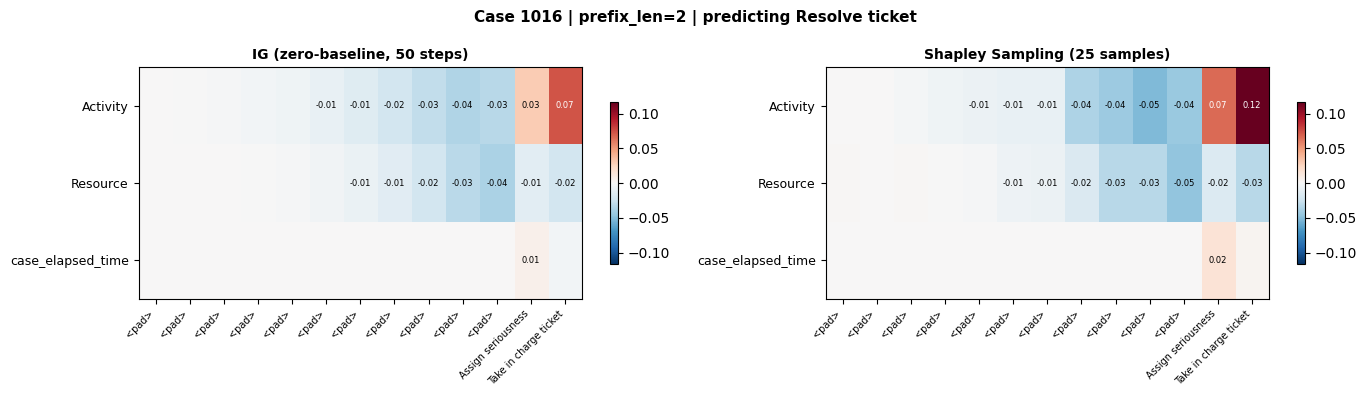

In [6]:
# Column labels
col_labels = [idx_to_name.get(a, '<pad>') if a != 0 else '<pad>' for a in cats_win[0][0].tolist()]
vmax = max(np.abs(mat_ig).max(), np.abs(mat_shap).max()) or 1.0

fig, axes = plt.subplots(1, 2, figsize=(14, max(4, 0.5 * len(feature_names) + 2)))
for ax, mat, title in zip(axes, [mat_ig, mat_shap], [
        f'IG (zero-baseline, {IG_STEPS} steps)',
        f'Shapley Sampling ({SHAP_SAMPLES} samples)']):
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
    im = ax.imshow(mat, cmap='RdBu_r', aspect='auto', norm=norm, interpolation='nearest')
    ax.set_yticks(range(len(feature_names)))
    ax.set_yticklabels(feature_names, fontsize=9)
    ax.set_xticks(range(len(col_labels)))
    ax.set_xticklabels(col_labels, rotation=45, ha='right', fontsize=7)
    ax.set_title(title, fontweight='bold', fontsize=10)
    fig.colorbar(im, ax=ax, shrink=0.7)
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            v = mat[i, j]
            if abs(v) > vmax * 0.05:
                color = 'white' if abs(v) > vmax * 0.5 else 'black'
                ax.text(j, i, f'{v:.2f}', ha='center', va='center', color=color, fontsize=6)
fig.suptitle(f'{CASE_NAME} | prefix_len={PREFIX_LENGTH} | predicting {target_name}', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

In [7]:
ig_totals = np.abs(mat_ig).sum(axis=1)
shap_totals = np.abs(mat_shap).sum(axis=1)
summary = pd.DataFrame({
    'Feature': feature_names,
    'IG total |attr|': ig_totals,
    'Shapley total |attr|': shap_totals,
})
summary.sort_values('IG total |attr|', ascending=False)

,Feature,IG total |attr|,Shapley total |attr|
0,Activity,0.254507,0.389465
1,Resource,0.151509,0.194915
2,case_elapsed_time,0.009299,0.018680
